# NASDAQ-100 microstructure: what a linear map of order flow is worth

This is the first model fitted in the case study, and deliberately the simplest one that can
use the whole feature set: a linear map from the microstructure features observed at one
minute to the return over the next fifteen.

Fitting it first is not a formality. A linear model cannot represent an interaction between
two features, so whatever it achieves is what the features provide on their own. Every later
model in this case study is more expressive and more expensive, and what each one adds is only
readable against this number.

The features are built from overlapping views of the same order flow - several spread
measures, several imbalance measures, and the same quantities at several lookbacks - so many
columns carry almost the same information. A design matrix like that is **collinear**, and
many different coefficient vectors fit the training window about equally well. Ordinary least
squares has no way to choose between them and will spend a large positive coefficient on one
feature against a large negative one on a near-copy. **Regularization** is the fix: penalize
coefficient size, so a solution that spreads weight across correlated features is preferred to
one that plays them off against each other. How much penalty is an empirical question, and the
grid below is the experiment that answers it.

**Learning objectives.** By the end of this notebook you will be able to:

- Read the set of models this case study declares for a label, and say which estimator and
  which hyperparameters each declared name resolves to.
- Bind those declarations to the data on disk and check, before anything is fitted, that every
  configuration will be measured on the same symbols, the same timestamps and the same folds.
- Fit a population of models on walk-forward folds and publish one complete set of validation
  predictions per configuration.
- Tell apart the two things a penalty can do to a collinear feature set - shrink correlated
  coefficients towards each other, or select a few and zero the rest - and read from the
  results which one order-flow data rewards.
- Recognise when an information coefficient is an artifact of a model that scored fewer
  decision times than its neighbours, and use coverage to rule it out.
- Run configurations of your own into a private copy of the run log, and have them compared on
  the same footing as the ones shipped here.

**Docker image**: `ml4t`

**Book reference**: Chapter 11, Section 11.2 (Regularized Linear Models). Chapter 6, Section
6.7 (Search accounting and run logging) introduces the run log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
and [`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds.

**What it writes**: one training run and one complete validation prediction set per
configuration, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`14_backtest`](14_backtest.ipynb) reads that population, runs every member against the
equal-weight baseline, and selects on validation backtest Sharpe. **Selection happens there,
not here.** This notebook ranks configurations by information coefficient to show what
regularization does to a collinear feature set; that ranking decides nothing.

In [1]:
"""Fit the declared NASDAQ-100 microstructure linear population on the validation folds."""

import re

import numpy as np
import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    plan_models,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABEL = "fwd_ret_15m"
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = "nasdaq100_microstructure-linear-validation-v1"

In [3]:
study = open_study(
    "nasdaq100_microstructure", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)

## 1. Which label, and which models

A label is the thing being predicted. This case study defines four in `config/setup.yaml`.
`fwd_ret_15m`, the return over the fifteen minutes after the decision minute, is the primary
one - the horizon the strategy chapters trade. `fwd_ret_5m` and `fwd_ret_60m` are the same
construction at shorter and longer horizons, kept so the effect of the prediction horizon can
be examined separately, and `fwd_dir_15m` is the classification form of the primary label.

**This notebook fits one label per run.** `LABEL` above selects it, and every choice below
follows from that one setting, because each label has its own training menu at
`config/training/{label}.yaml`. The menu lists, family by family, the named configurations to
fit for that label.

In [4]:
declared_labels(study, "linear")

('fwd_dir_15m', 'fwd_ret_15m', 'fwd_ret_5m', 'fwd_ret_60m')

Each name in the menu resolves to a preset file in the shared directory
`case_studies/config/{model_type}/`, which holds that configuration's hyperparameters. The
frame below is the menu for `LABEL`, with each name resolved to the estimator class it names
and the arguments that class is constructed with. To change what runs, edit the menu or the
presets rather than this notebook.

The grid covers the two shapes a penalty can take:

- **Ridge** penalizes the sum of squared coefficients. It shrinks correlated coefficients
  towards each other and keeps every feature, at a strength set by `alpha`. The grid steps
  `alpha` by powers of ten across eleven orders of magnitude, because the useful value depends
  on the scale and the collinearity of the design matrix and neither is known in advance.
- **Lasso** penalizes the sum of absolute coefficients, which drives some of them exactly to
  zero: it selects features rather than shrinking them. **ElasticNet** mixes the two.

Lasso and ElasticNet are parameterized here by `alpha_frac` rather than a raw penalty. For any
fold there is a threshold penalty $\alpha_{\max}$ - the smallest one that zeros every
coefficient - computed from that fold's own data. `alpha_frac` is the fraction of it to apply,
so one declared `alpha_frac` means the same thing on every fold, while a fixed raw penalty
would mean something different on each.

In [5]:
configs = load_model_configs(
    study,
    "linear",
    labels=[LABEL],
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""linear""","""fwd_ret_15m""","""ols""","""LinearRegression""","""defaults"""
"""linear""","""fwd_ret_15m""","""ridge_a0.001""","""Ridge""","""alpha=0.001"""
"""linear""","""fwd_ret_15m""","""ridge_a0.01""","""Ridge""","""alpha=0.01"""
"""linear""","""fwd_ret_15m""","""ridge_a0.1""","""Ridge""","""alpha=0.1"""
"""linear""","""fwd_ret_15m""","""ridge_a1.0""","""Ridge""","""alpha=1.0"""
…,…,…,…,…
"""linear""","""fwd_ret_15m""","""ridge_a10000000.0""","""Ridge""","""alpha=10000000.0"""
"""linear""","""fwd_ret_15m""","""lasso_a0.01""","""Lasso""","""alpha=0.01, max_iter=1000"""
"""linear""","""fwd_ret_15m""","""lasso_a0.1""","""Lasso""","""alpha=0.1, max_iter=1000"""


## 2. Binding the declarations to the data

A menu entry says which estimator to fit. It does not say which feature columns exist today,
where the walk-forward folds fall, or which symbol-timestamp pairs have both a feature row and
a label. **Resolving** a request is the step that goes and finds all of that: it reads the
label and feature files, computes the fold boundaries from the walk-forward parameters in
`config/setup.yaml`, works out the exact set of rows each fit is expected to predict, and
turns any data-dependent hyperparameter into the number it will actually use - each fold's own
$\alpha_{\max}$ times `alpha_frac`, in the case of Lasso.

**Planning** derives all of that without holding it. `plan_models` works out every training
and prediction identity from the declarations and placeholder folds, so the whole panel of
configurations is priced before a single fit, and nothing but the plan is alive when it
finishes. Resolving each request instead would be equivalent arithmetic at ruinous cost here:
a resolved request carries its prepared folds, and this case study is a minute panel, so
holding one per configuration means holding the same standardized design matrix sixteen times
over. Execution then walks folds on the outside and configurations on the inside, so one fold
set is live at a time however many configurations were declared.

The plan is the population, written down before anything is fitted. Two things to check in it:

- **One row per configuration and checkpoint**, matching the catalog above. A missing row is a
  configuration that will not be fitted, and a run that later produces a different set than it
  declared here fails rather than quietly publishing what it happened to produce.
- **`training_hash` differs wherever the configurations differ, and repeats wherever they do
  not.** Two configurations that resolve to the same computation share an identity and are
  fitted once; two that differ must not collide.

The `training_hash` is the identity of that computation, derived from everything that can
change its result. [`RUN_LOG.md`](../RUN_LOG.md#identity) sets out what goes into one and what
follows from it.

In [6]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
plan = plan_models(study, requests=requests)

pl.DataFrame(
    {
        "config_name": [member.config_name for member in plan.members],
        "checkpoint_kind": [member.checkpoint_kind for member in plan.members],
        "checkpoint_value": [member.checkpoint_value for member in plan.members],
        "training_hash": [member.training_hash for member in plan.members],
        "prediction_hash": [member.prediction_hash for member in plan.members],
    }
)

config_name,checkpoint_kind,checkpoint_value,training_hash,prediction_hash
str,str,null,str,str
"""ols""","""final""",null,"""be0a64c4c19c""","""16db0508b846"""
"""ridge_a0.001""","""final""",null,"""e2ddbfe912ee""","""8401c246da1a"""
"""ridge_a0.01""","""final""",null,"""6a0ea48cb3d1""","""a619f64838b5"""
"""ridge_a0.1""","""final""",null,"""29f8a0010435""","""adad3964a723"""
"""ridge_a1.0""","""final""",null,"""b63b9b3fe3ed""","""85f47606664f"""
…,…,…,…,…
"""ridge_a10000000.0""","""final""",null,"""292a17362d8c""","""cc0e6ba74107"""
"""lasso_a0.01""","""final""",null,"""0a09e31a5437""","""5067fa7d9040"""
"""lasso_a0.1""","""final""",null,"""6ffe6992fbe0""","""edc7052b87f2"""


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. fills missing feature values with the training window's median for that column, then
   standardizes each column to zero mean and unit variance - both fitted on training rows only
   and then applied to the validation rows, so nothing from the validation window reaches the
   fit,
3. fits the estimator with that fold's resolved parameters,
4. predicts the fold's validation rows.

The fold predictions are concatenated into one series covering the whole validation period,
which is what a walk-forward prediction set is: each timestamp predicted by a model that saw
only data before it. The run then writes a `training_runs` row and the fitted coefficients, a
`prediction_sets` row and the predictions themselves, and the metrics computed from them. It
does this per configuration rather than once at the end, so an interruption costs the
configuration in flight and nothing else.

Every case study that fits linear models calls this same runner, which is what makes their
results comparable. Unlike gradient boosting or a neural network, a linear model has no
intermediate states worth scoring: there is one fit and therefore one checkpoint per
configuration, and no learning curve to plot.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
is going to produce. The list is computed from the resolved specifications before the first fit
and written down, and afterwards every member must exist and be complete. That is what makes
the downstream comparison well defined - `14_backtest` backtests this population, not whatever
predictions happen to be in the registry - and it is why a configuration that raises fails the
whole call rather than publishing a population one member short. Everything that finished stays
registered, and re-running fits only what is missing.

In [7]:
execution, population = run_model_population(study, plan, population_name=POPULATION_NAME)

fitted = sum(len(item["fitted_folds"]) for item in execution.diagnostics)
reused = sum(len(item["reused_folds"]) for item in execution.diagnostics)
print(f"{len(execution.runs)} configurations: {fitted} folds fitted, {reused} reused")
print(f"population {population.name}: {len(population.members)} prediction sets")

16 configurations: 0 folds fitted, 32 reused
population nasdaq100_microstructure-linear-validation-v1: 16 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the
registry already holds the matching rows, and the runner returns the stored result rather than
fitting again - so re-running this notebook unchanged costs the time it takes to read the data.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which
holds its own registry and artifacts and reads the same labels and features:

```python
study = open_study("nasdaq100_microstructure", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "linear", labels=["fwd_ret_15m"], config_names=["ols", "ridge_a1.0", "ridge_a10.0"]
)
requests = model_requests(study, configs)
plan = plan_models(study, requests=requests)
execution, population = run_model_population(study, plan, population_name="my-linear-v1")
```

`CONFIG_NAMES` fits a subset of what the menu already declares; a name the menu does not
declare raises rather than quietly fitting fewer models than you asked for. To fit something
new, add a preset at `case_studies/config/ridge/ridge_a3.0.yaml` and list `ridge_a3.0` under
`linear:` in the label's menu. Editing an existing preset changes that configuration's
identity, so its result registers as a new row beside the old one instead of replacing it.

Give the run its own `population_name`: a name refers to one set of members permanently, and
reusing it for a different set raises. Everything downstream reads the registry rather than the
notebook, so predictions produced this way are selected and backtested on the same footing as
the ones shipped here.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest, including how to
rehearse on a reduced universe first.

## 4. What came out

One row per configuration, read back from the registry. `ic_mean` is the **information
coefficient**: at each decision time, rank the constituents by the model's prediction, rank
them by the return they went on to earn over the next fifteen minutes, correlate the two
rankings, and average that correlation over the validation period. It measures whether the
model ranks names correctly, on a scale where zero is no relationship. Intraday values are
smaller than the daily-horizon ICs elsewhere in the book: a fifteen-minute return is mostly
noise, and a few thousandths of consistent rank correlation is a real effect at this horizon.

**`ic_n_days` does not count days here.** The column is named for the daily case studies, where
one decision date produces one cross-section. This case study decides every fifteen minutes,
so the stored count is a count of *decision times* - tens of thousands of them across the
validation period, not hundreds. It is still the right thing to compare configurations on,
because every configuration is counted the same way, but do not read it as a number of trading
days.

What the count is for: a model whose coefficients collapse to one or two features predicts
nearly the same value for every constituent at some timestamps, and a constant has no rank
correlation with anything, so those timestamps contribute nothing. Its `ic_mean` is then an
average over fewer decision times than its neighbours', chosen by where it happened to stay
non-degenerate, and comparing it with theirs compares two different samples. `full_coverage`
marks the configurations measured on all of them. A cross-section also has to be wide enough
to rank at all: a timestamp scores only where at least five constituents carry both a finite
prediction and a finite realized return.

In [8]:
catalog = (
    execution.catalog_rows.select(
        "config_name",
        "label",
        "complete",
        "ic_mean",
        "ic_std",
        "ic_n_days",
        "n_folds",
        "training_hash",
        "prediction_hash",
    )
    .sort("ic_mean", descending=True)
    .join(configs.select("config_name", "model_class", "params"), on="config_name", how="left")
)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("linear execution returned a partial prediction set")

full_times = int(catalog.get_column("ic_n_days").max())
catalog = catalog.with_columns(full_coverage=pl.col("ic_n_days") == full_times)
print(f"full coverage is {full_times:,} scored decision times")
catalog.select(
    "config_name",
    "model_class",
    "params",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
)

full coverage is 79,082 scored decision times


config_name,model_class,params,ic_mean,ic_std,ic_n_days,full_coverage
str,str,str,f64,f64,f64,bool
"""ridge_a1000000.0""","""Ridge""","""alpha=1000000.0""",0.00457,0.000138,79082.0,true
"""ridge_a100000.0""","""Ridge""","""alpha=100000.0""",0.003856,0.001425,79082.0,true
"""ridge_a10000.0""","""Ridge""","""alpha=10000.0""",0.003649,0.001973,79082.0,true
"""ridge_a0.001""","""Ridge""","""alpha=0.001""",0.003585,0.002096,79082.0,true
"""ridge_a0.01""","""Ridge""","""alpha=0.01""",0.003584,0.002096,79082.0,true
…,…,…,…,…,…,…
"""enet_a0.1""","""ElasticNet""","""alpha=0.1, l1_ratio=0.5, max_i…",1.9946e-16,0.0,37449.0,false
"""lasso_a0.01""","""Lasso""","""alpha=0.01, max_iter=1000""",1.9946e-16,0.0,37449.0,false
"""enet_a0.01""","""ElasticNet""","""alpha=0.01, l1_ratio=0.5, max_…",1.9946e-16,0.0,37449.0,false


### How the penalty grid ranks

Only the configurations measured at all `full_times` decision times are charted. The
partial-coverage ones are in the table above with `full_coverage` false, and are left out here
because their IC is an average over a different set of timestamps.

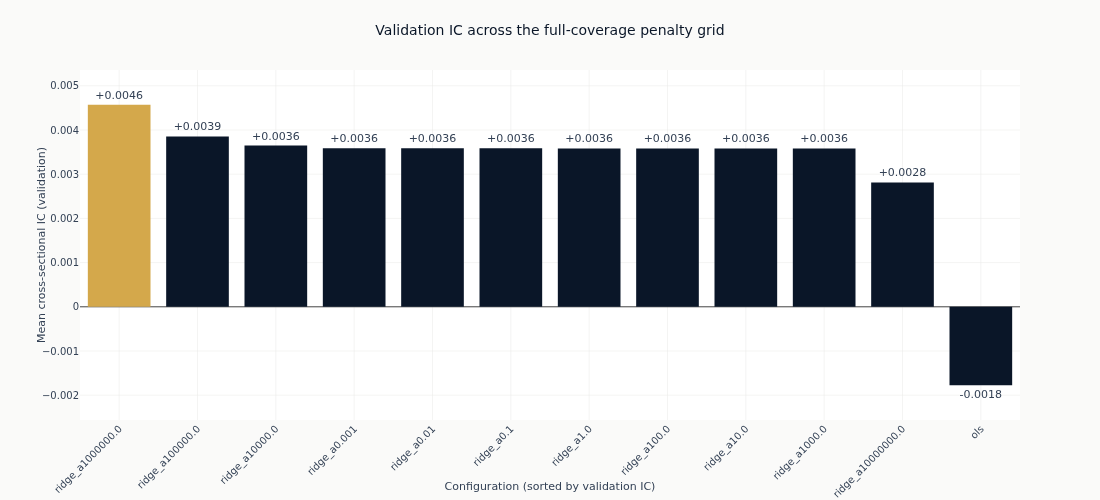

In [9]:
def compact(params: str) -> str:
    """Render declared parameters for a title: `alpha=1000000.0` reads as `alpha=1e+06`."""
    return re.sub(r"\d+\.?\d*(?:[eE][+-]?\d+)?", lambda m: f"{float(m.group()):g}", params)


full = catalog.filter("full_coverage")
leader = full.row(0, named=True)

fig_ic = go.Figure(
    go.Bar(
        x=full.get_column("config_name").to_list(),
        y=full.get_column("ic_mean").to_list(),
        marker_color=[
            COLORS["amber"] if name == leader["config_name"] else COLORS["blue"]
            for name in full.get_column("config_name")
        ],
        text=[f"{value:+.4f}" for value in full.get_column("ic_mean")],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_ic.update_layout(
    title="Validation IC across the full-coverage penalty grid",
    height=500,
    width=1100,
    showlegend=False,
    margin=dict(t=70),
)
fig_ic.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_ic.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_ic,
    "Bar chart of mean validation information coefficient for every full-coverage linear "
    f"configuration, sorted descending. {leader['config_name']} ({compact(leader['params'])}) "
    f"is highlighted in amber at the top of the ranking at IC {leader['ic_mean']:+.4f}. Values "
    "across the grid are a few thousandths, the scale a fifteen-minute horizon supports.",
)

### What shrinkage does on its own

The bar chart mixes three estimators. Tracing IC across the Ridge penalty alone isolates the
effect of shrinkage, with the estimator, the features and the folds all held fixed and only
`alpha` moving. The alpha is read from each configuration's declared parameters rather than
parsed out of its name, so the curve plots what was fitted.

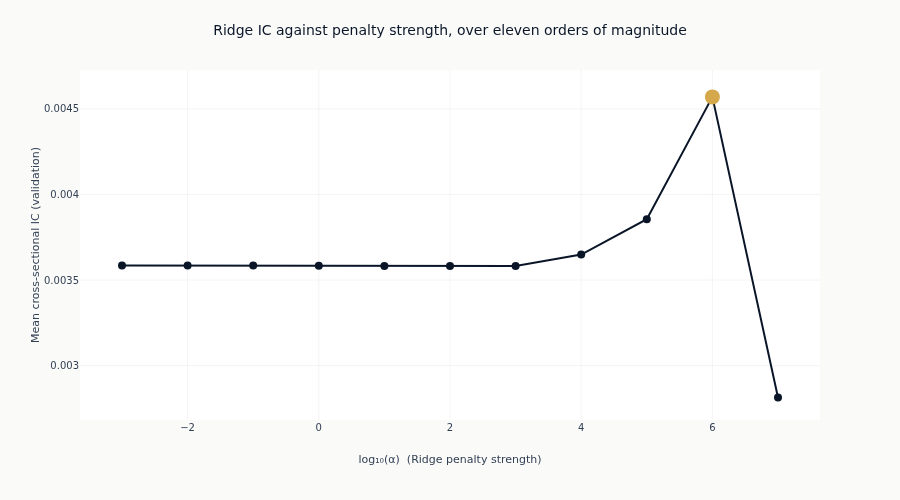

In [10]:
ridge = (
    catalog.filter(pl.col("model_class") == "Ridge")
    .with_columns(
        alpha=pl.col("params").str.extract(r"alpha=([0-9.eE+-]+)").cast(pl.Float64),
    )
    .drop_nulls("alpha")
    .sort("alpha")
)
if ridge.height:
    log_alpha = np.log10(ridge.get_column("alpha").to_numpy())
    ridge_ic = ridge.get_column("ic_mean").to_numpy()
    peak = int(np.argmax(ridge_ic))

    fig_alpha = go.Figure(
        go.Scatter(
            x=log_alpha,
            y=ridge_ic,
            mode="lines+markers",
            line=dict(color=COLORS["blue"], width=2),
            marker=dict(size=8, color=COLORS["blue"]),
        )
    )
    fig_alpha.add_trace(
        go.Scatter(
            x=[log_alpha[peak]],
            y=[ridge_ic[peak]],
            mode="markers",
            marker=dict(size=15, color=COLORS["amber"]),
            showlegend=False,
        )
    )
    fig_alpha.update_layout(
        title="Ridge IC against penalty strength, over eleven orders of magnitude",
        height=500,
        width=900,
        showlegend=False,
        margin=dict(t=70),
    )
    fig_alpha.update_xaxes(title_text="log₁₀(α)  (Ridge penalty strength)", zeroline=False)
    fig_alpha.update_yaxes(title_text="Mean cross-sectional IC (validation)")
    show_plotly_with_alt(
        fig_alpha,
        "Line chart of mean validation information coefficient against the base-ten logarithm of "
        "the Ridge penalty, over eleven orders of magnitude. The curve is flat where the penalty "
        f"is too weak to bind and peaks at 1e{int(round(log_alpha[peak]))}, marked in amber.",
    )
else:
    print(
        f"{LABEL} declares no Ridge configurations, so there is no penalty sweep to trace. "
        f"Which estimators this section can show is decided by the menu at "
        f"config/training/{LABEL}.yaml."
    )

## 5. What to notice

**Where the Ridge curve turns tells you how collinear the design matrix is.** It is flat while
the penalty is too weak to bind, rises as shrinkage starts collapsing groups of near-duplicate
order-flow features onto their common direction, and falls once the penalty is strong enough to
erode the signal along with the noise. The distance from the peak back to unregularized OLS is
the part of the signal that multicollinearity was burying. On a feature set that was close to
orthogonal the same curve would be nearly flat, and that comparison is worth making on your own
data before spending a grid on it.

**Read the ranking with the coverage column or it will mislead you.** The most aggressive L1
settings can post a high raw IC while not being comparable to the rest: they zero all but a
couple of features on several folds, predict a near-constant value at those timestamps, and
contribute no correlation there. Read without `ic_n_days` such a table says hard feature
selection wins; read with it, the same table says those configurations failed on part of the
sample. The general lesson is that a metric averaged over a set the model itself selected is
not a metric.

**The absolute level is small, and that is the honest reading of a fifteen-minute horizon.**
A daily-horizon equity signal reports IC in the hundredths; here a few thousandths is what a
working signal looks like, because almost all of a fifteen-minute return is noise. Whether that
is tradable is not answerable from IC at all - at this horizon the position turns over
constantly, so costs decide it, and costs are not in this notebook.

**None of this selects anything.** IC measures whether predictions rank names correctly, not
whether a strategy trading them makes money after costs and turnover. Those are different
questions and a configuration can win the first while losing the second. Selection is on
validation backtest Sharpe over the population this notebook just published, and it happens in
[`14_backtest`](14_backtest.ipynb).

**Known limitations.** The IC here is an average of per-timestamp rank correlations with no
adjustment for the serial dependence that overlapping fifteen-minute returns create, so it is a
ranking diagnostic rather than a test. The grid is a one-dimensional sweep of penalty strength
at fixed features and fixed folds, so it says nothing about interactions between the penalty
and either. And every number here is measured on the validation folds, which have been read
many times over by the time a case study reaches this notebook.

**Next**: [`07_gbm`](07_gbm.ipynb) asks whether gradient boosting can find interactions in the
order flow that a linear map cannot represent at all.